In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 드라이브 마운트 후 파일 목록을 확인하려면 아래 코드를 사용하세요.
import os
drive_path = '/content/drive/My Drive'

In [ ]:
import pandas as pd

# 파일 경로 설정
file_path = '/content/drive/MyDrive/SK_NETWORKS/2ND-1TEAM/Telco_customer_churn - Telco_Churn.csv'

try:
    # 데이터 로드
    df = pd.read_csv(file_path)
    print('데이터를 성공적으로 불러왔습니다.')
    display(df.head())
except Exception as e:
    print(f'파일을 불러오는 중 오류가 발생했습니다: {e}')

데이터를 성공적으로 불러왔습니다.


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


## EDA

In [ ]:
# 결측치가 있는 'Churn Reason' 컬럼을 'Not Disclosed'로 채웁니다.
df['Churn Reason'] = df['Churn Reason'].fillna('Not Disclosed')

# 결측치 처리가 잘 되었는지 다시 확인합니다.
print("결측치 처리 후 현황:")
print(df.isnull().sum())

display(df.head())

결측치 처리 후 현황:
CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 월 요금 영향 관계분석

/tmp/ipykernel_711/2860052921.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Monthly Charges', data=df, palette='Set2')


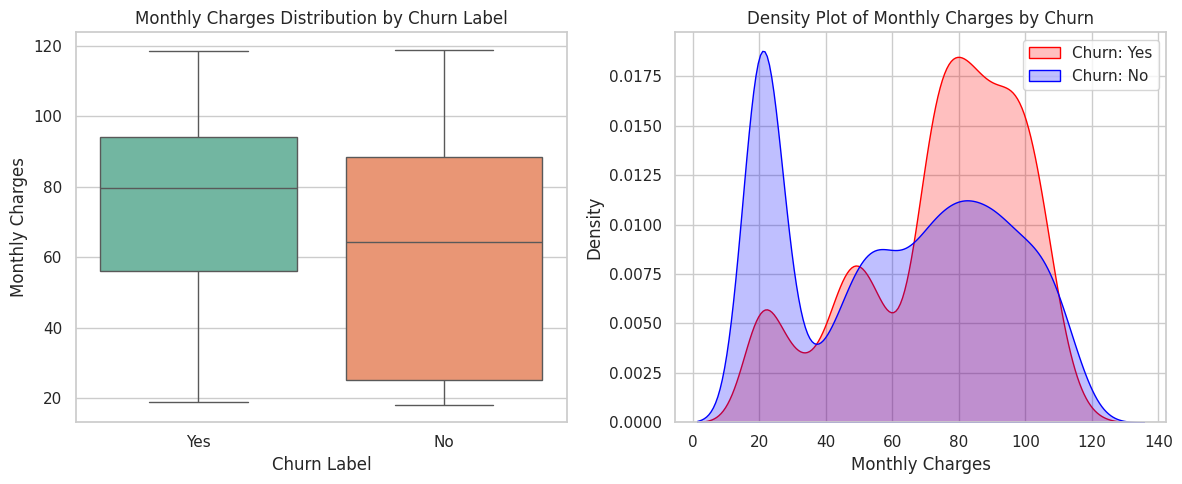

Churn Label에 따른 평균 Monthly Charges:
Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set(style='whitegrid')

# 박스 플롯 (Box Plot)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df, palette='Set2')
plt.title('Monthly Charges Distribution by Churn Label')

# 히스토그램 (KDE Plot)
plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Churn Label'] == 'Yes']['Monthly Charges'], label='Churn: Yes', fill=True, color='red')
sns.kdeplot(df[df['Churn Label'] == 'No']['Monthly Charges'], label='Churn: No', fill=True, color='blue')
plt.title('Density Plot of Monthly Charges by Churn')
plt.legend()

plt.tight_layout()
plt.show()

# 평균 요금 비교 수치 확인
mean_charges = df.groupby('Churn Label')['Monthly Charges'].mean()
print("Churn Label에 따른 평균 Monthly Charges:")
print(mean_charges)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

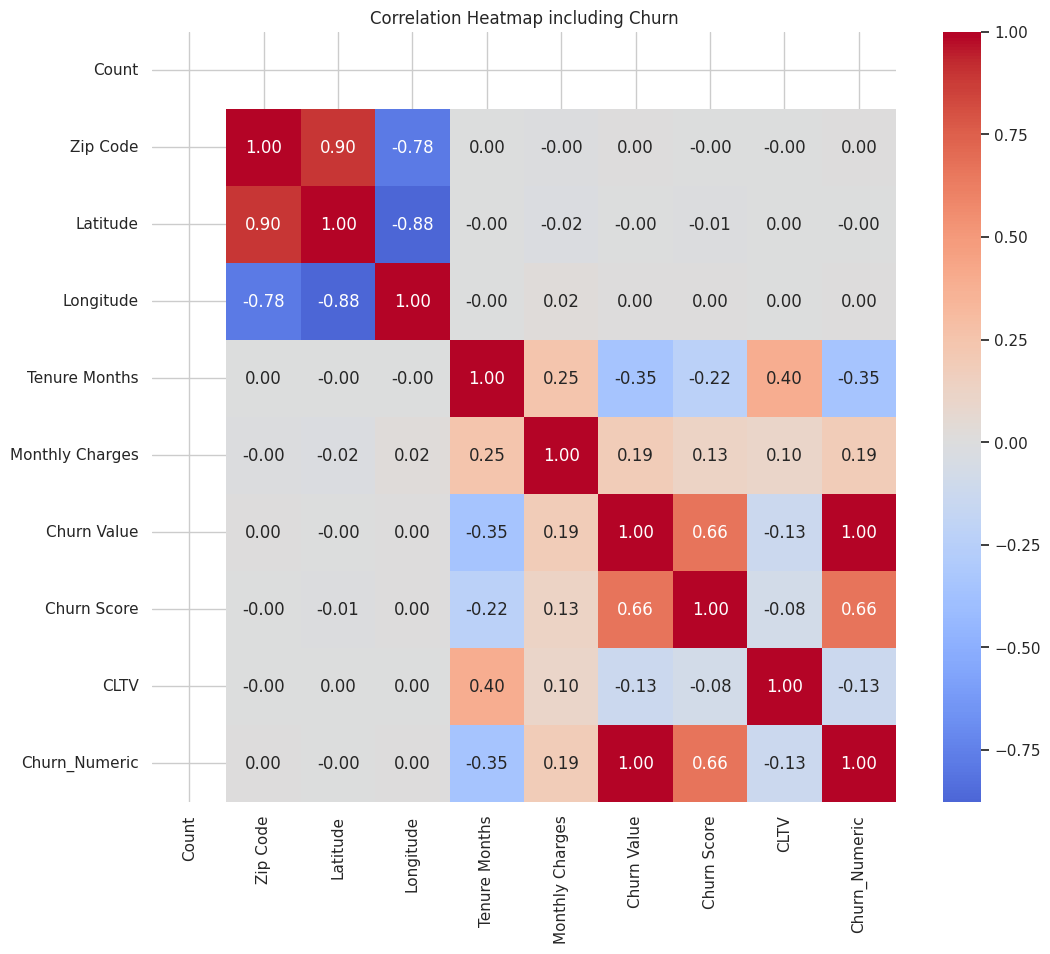

Churn Label과의 상관계수 순위:
Churn_Numeric      1.000000
Churn Value        1.000000
Churn Score        0.664897
Monthly Charges    0.193356
Longitude          0.004594
Zip Code           0.003346
Latitude          -0.003384
CLTV              -0.127463
Tenure Months     -0.352229
Count                   NaN
Name: Churn_Numeric, dtype: float64


In [ ]:
import numpy as np

# 상관관계 분석을 위해 Churn Label을 수치형으로 변환 (Yes=1, No=0)
df['Churn_Numeric'] = df['Churn Label'].apply(lambda x: 1 if x == 'Yes' else 0)

# 수치형 컬럼들만 선택
numeric_df = df.select_dtypes(include=[np.number])

# 상관계수 계산
corr_matrix = numeric_df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap including Churn')
plt.show()

# Churn_Numeric과 상관관계가 높은 순서대로 출력
print('Churn Label과의 상관계수 순위:')
print(corr_matrix['Churn_Numeric'].sort_values(ascending=False))

/tmp/ipykernel_711/3878853334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn_Numeric', data=df, palette='viridis')
/tmp/ipykernel_711/3878853334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn_Numeric', data=df, palette='viridis')
/tmp/ipykernel_711/3878853334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Churn_Numeric', data=df, palette='viridis')
/tmp/ipykernel_711/3878853334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

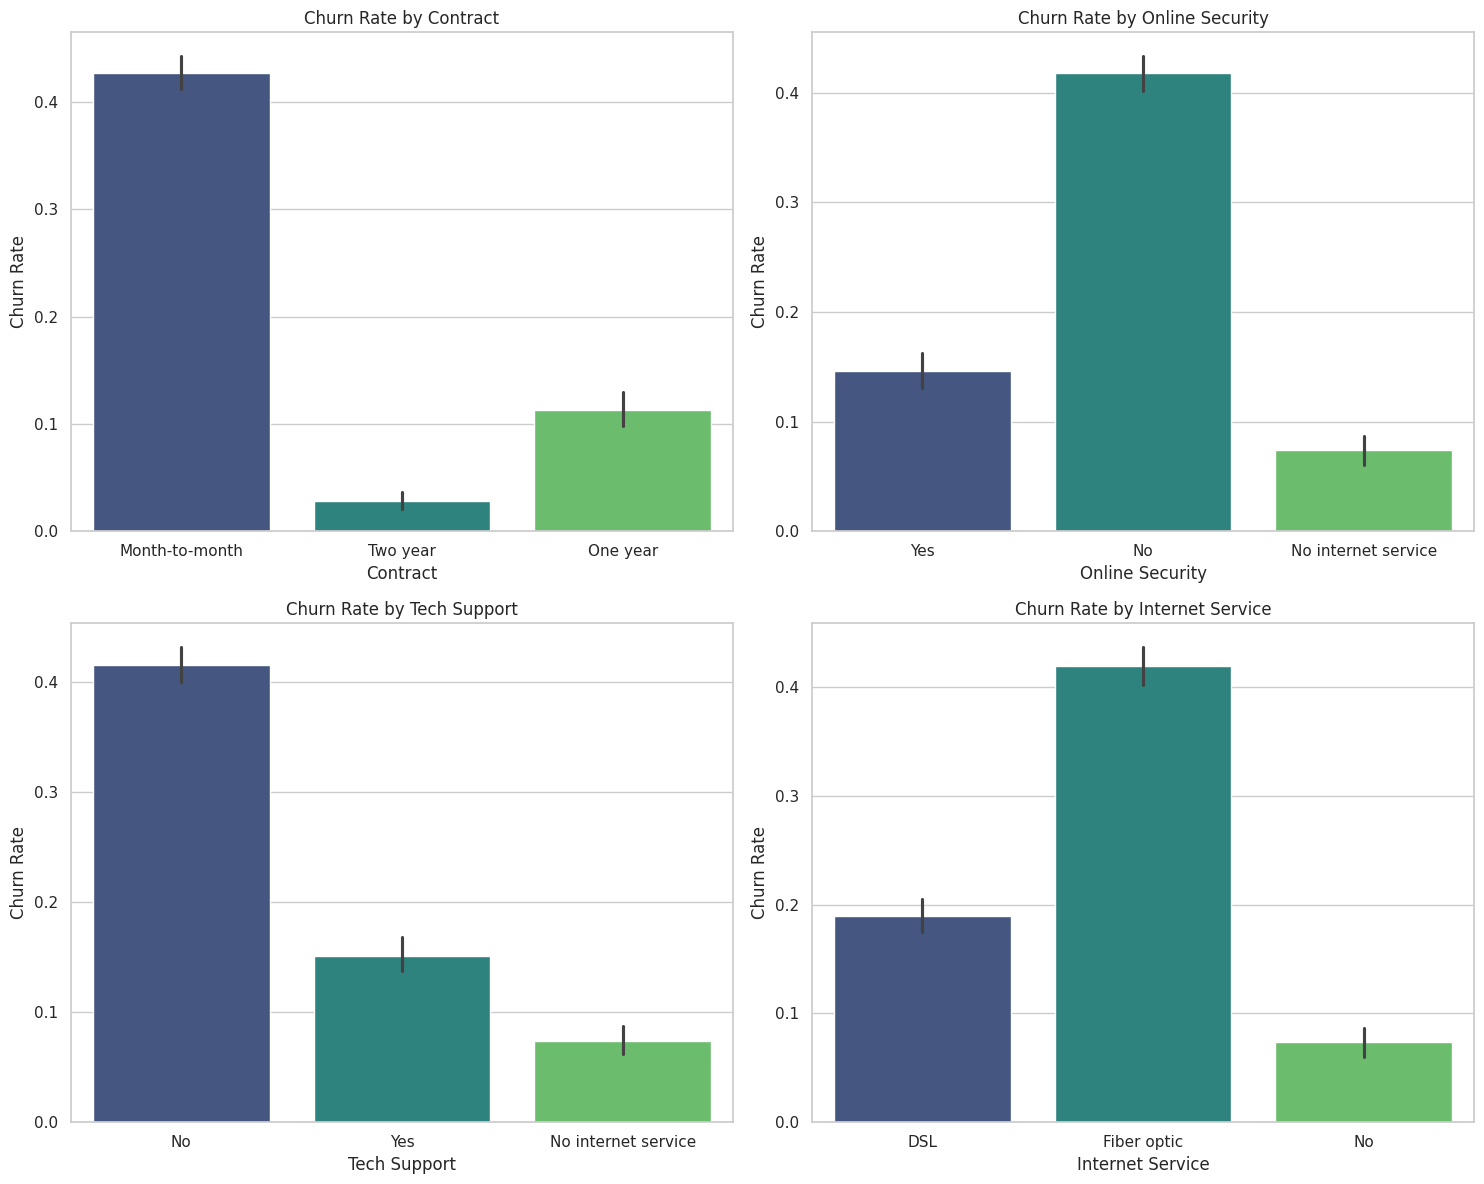

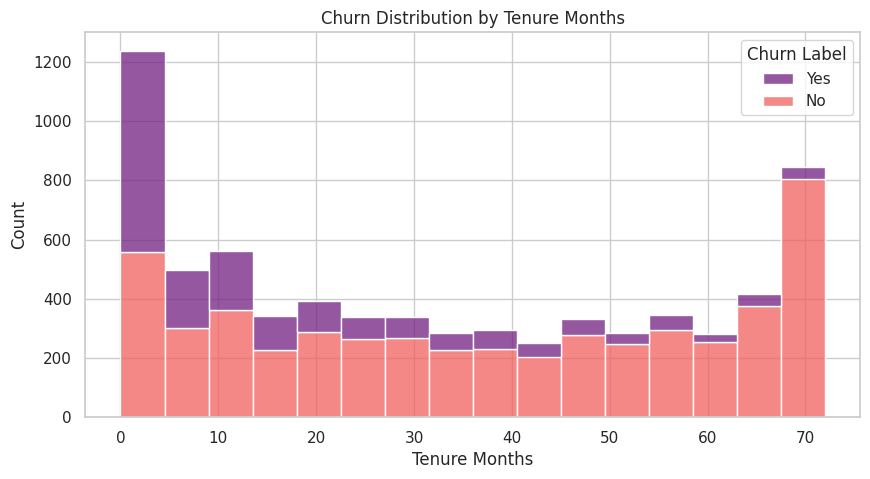

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 분석할 주요 범주형 컬럼들
features = ['Contract', 'Online Security', 'Tech Support', 'Internet Service']

plt.figure(figsize=(15, 12))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    # 각 항목별 이탈률(Churn Value의 평균) 계산 및 시각화
    sns.barplot(x=col, y='Churn_Numeric', data=df, palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()

# 이용 기간(Tenure Months)에 따른 이탈 분포
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', multiple='stack', palette='magma')
plt.title('Churn Distribution by Tenure Months')
plt.show()

## Feature Engineering

In [ ]:
#  데이터 타입 변환 (문자열 -> 숫자형, 공백은 NaN 처리 후 0으로 채움)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

#  월 단위 계약 여부
df['Is_Month_To_Month'] = df['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)

#  보안 및 기술 지원 서비스 미이용 여부
df['No_Security_Support'] = ((df['Online Security'] == 'No') & (df['Tech Support'] == 'No')).astype(int)

#  6개월 이하 신규 고객 여부
df['New_Customer'] = df['Tenure Months'].apply(lambda x: 1 if x <= 6 else 0)

# 고위험군 (Fiber Optic + Month-to-month)
df['High_Risk_Fiber'] = ((df['Internet Service'] == 'Fiber optic') & (df['Contract'] == 'Month-to-month')).astype(int)

# --- [고도화된 파생 변수 생성] ---
services = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

# Total_Services: 가입한 부가서비스 총 개수 (0~6개)
df['Total_Services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Extra_Charges: 총 누적 요금에서 (월 요금 × 가입 개월 수)를 뺀 추가 요금
df['Extra_Charges'] = df['Total Charges'] - (df['Monthly Charges'] * df['Tenure Months'])

# Price_per_Service: 서비스 1개당 체감 단가
df['Price_per_Service'] = df['Monthly Charges'] / (df['Total_Services'] + 1)

# Full_Family: 배우자와 부양가족이 모두 있는 고객
df['Full_Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)

# Single_Senior: 65세 이상 1인 가구
df['Single_Senior'] = ((df['Senior Citizen'] == 'Yes') & (df['Partner'] == 'No') & (df['Dependents'] == 'No')).astype(int)

# Auto_Payment: 자동 결제 등록 여부
df['Auto_Payment'] = df['Payment Method'].str.contains('automatic').astype(int)



# --- [페르소나 위험군 변수] ---
# 경쟁사 속도 마케팅 취약군 (광랜 + 무약정 + 특정 기간 이용)
df['Speed_Competitor_Risk'] = ((df['Internet Service'] == 'Fiber optic') & (df['Contract'] == 'Month-to-month') & (df['Tenure Months'].between(6, 24))).astype(int)

# 가격 민감 위험군 (고액 요금 + 무약정 + 부양가족 없음)
df['Price_Sensitive_Risk'] = ((df['Monthly Charges'] > df['Monthly Charges'].median()) & (df['Contract'] == 'Month-to-month') & (df['Dependents'] == 'No')).astype(int)

# 기술 지원 결핍 위험군 (기술 지원/보안 서비스 없음 + 인터넷 사용 중)
df['Tech_Lacking_Risk'] = ((df['Tech Support'] == 'No') & (df['Online Security'] == 'No') & (df['Internet Service'] != 'No')).astype(int)

# --- [추가 리스크 플래그] ---
df['Early_Churn_Risk'] = ((df['Tenure Months'] <= 3) & (df['Contract'] == 'Month-to-month')).astype(int)
df['Hidden_Fee_Flag'] = (df['Extra_Charges'] > 0).astype(int)
df['Loyal_But_Unbound'] = ((df['Tenure Months'] >= 24) & (df['Contract'] == 'Month-to-month')).astype(int)

display(df[['Extra_Charges', 'Total_Services', 'Speed_Competitor_Risk', 'Price_Sensitive_Risk']].head())

,Extra_Charges,Total_Services,Speed_Competitor_Risk,Price_Sensitive_Risk
0,0.45,2,0,0
1,10.25,0,0,0
2,23.30,3,1,0
3,111.65,4,0,0
4,-45.00,4,0,0


In [ ]:
# Total Charges를 수치형으로 변환 (공백 처리 포함)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# 1. 이용 기간 대비 평균 청구 금액
df['Avg_Monthly_Bill'] = df['Total Charges'] / (df['Tenure Months'] + 1)

# 2. 이용 중인 총 서비스 개수
service_cols = ['Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
                'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
# 'No'가 아닌 것들의 개수를 합산
df['Total_Services'] = df[service_cols].apply(lambda x: x.str.contains('Yes|Fiber optic|DSL').sum(), axis=1)

# 3. 스트리밍 헤비 유저 여부
df['Streaming_Heavy_User'] = ((df['Streaming TV'] == 'Yes') & (df['Streaming Movies'] == 'Yes')).astype(int)

# 4. 결합 지수 (충성도 지표)
# 1년 이상 약정 + 자동이체 + 보안 서비스 중 하나라도 이용
df['Engagement_Score'] = (
    (df['Contract'].isin(['One year', 'Two year'])).astype(int) +
    (df['Payment Method'].str.contains('automatic')).astype(int) +
    ((df['Online Security'] == 'Yes') | (df['Tech Support'] == 'Yes')).astype(int)
)

display(df[['Avg_Monthly_Bill', 'Total_Services', 'Streaming_Heavy_User', 'Engagement_Score']].head())

# 이탈과의 상관관계 재확인
added_features = ['Avg_Monthly_Bill', 'Total_Services', 'Streaming_Heavy_User', 'Engagement_Score', 'Churn_Numeric']
print('\n추가된 변수와 이탈 간의 상관계수:')
display(df[added_features].corr()['Churn_Numeric'].sort_values(ascending=False))

,Avg_Monthly_Bill,Total_Services,Streaming_Heavy_User,Engagement_Score
0,36.050000,4,0,1
1,50.550000,2,0,0
2,91.166667,6,1,0
3,105.036207,7,1,1
4,100.726000,7,1,1



추가된 변수와 이탈 간의 상관계수:


,Churn_Numeric
Churn_Numeric,1.000000
Avg_Monthly_Bill,0.072579
Streaming_Heavy_User,0.040441
Total_Services,-0.019375
Engagement_Score,-0.375073


--- 중요도 하위 변수 (제거 후보 3개) ---
['New_Customer', 'Hidden_Fee_Flag', 'Tech_Lacking_Risk']


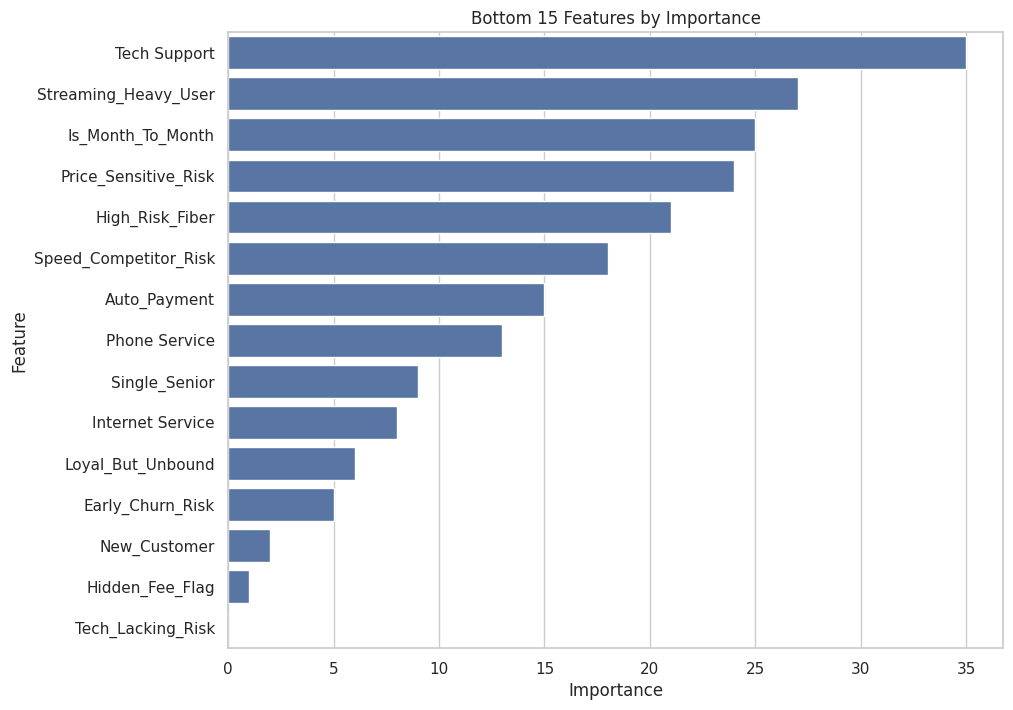

In [ ]:
import pandas as pd
import numpy as np

# 앙상블 모델 내 LightGBM의 변수 중요도 추출
lgbm_feat_importance = voting_model.named_estimators_['lgbm'].feature_importances_

# 변수 중요도 데이터프레임 생성
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_feat_importance
}).sort_values(by='Importance', ascending=False)

# 중요도가 매우 낮은 (예: 상위 90%에 포함되지 못하거나 중요도 5 미만) 변수 추출
low_importance_threshold = 5
drop_candidates = feature_imp_df[feature_imp_df['Importance'] < low_importance_threshold]['Feature'].tolist()

print(f"--- 중요도 하위 변수 (제거 후보 {len(drop_candidates)}개) ---")
print(drop_candidates)

# 중요도 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.tail(15))
plt.title('Bottom 15 Features by Importance')
plt.show()

## TOP 10 이탈 사유

/tmp/ipykernel_711/527208465.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=churn_reasons.index, x=churn_reasons.values, palette='magma')


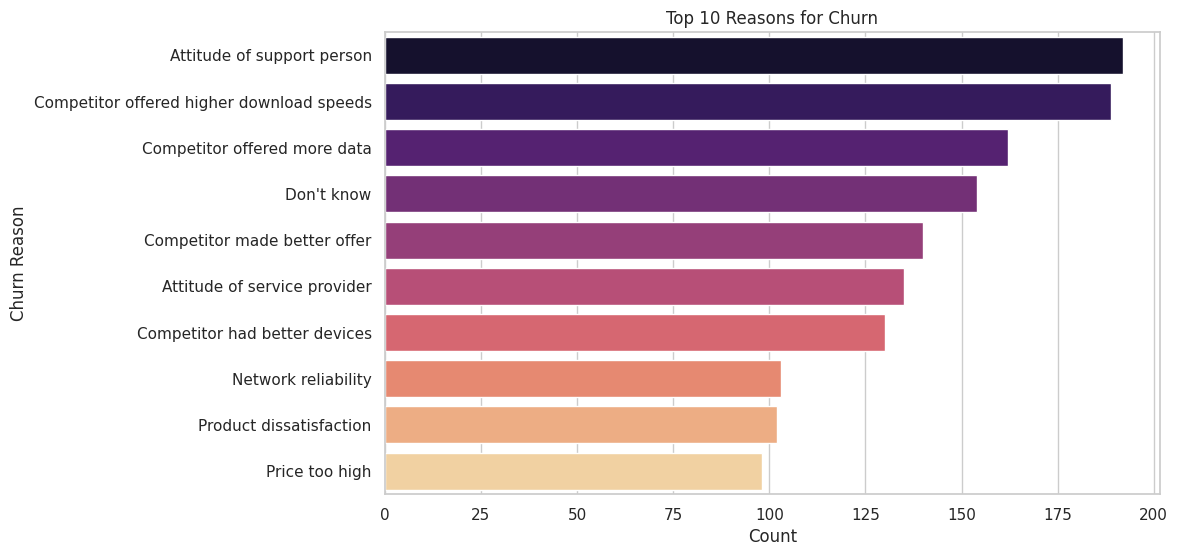

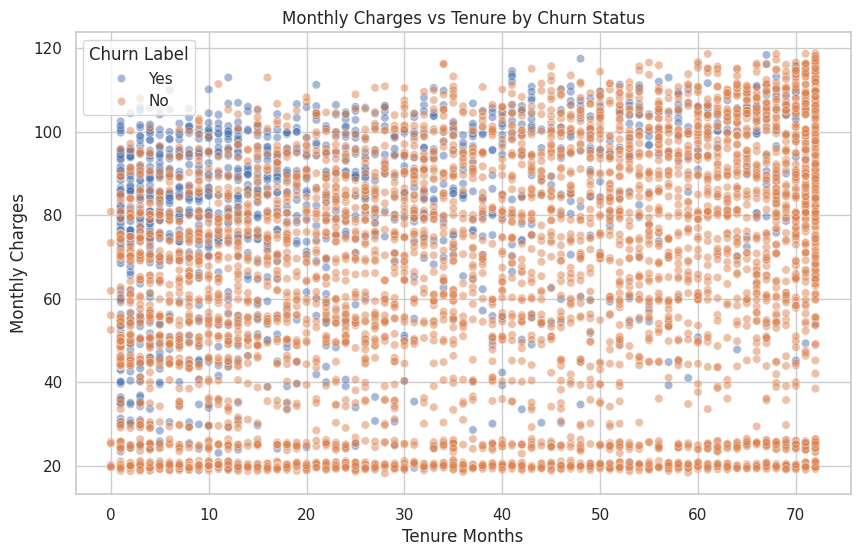

In [ ]:
# 1. 이탈 사유(Churn Reason) 상위 10개 분석 (이탈 고객 대상)
plt.figure(figsize=(10, 6))
churn_reasons = df[df['Churn Label'] == 'Yes']['Churn Reason'].value_counts().head(10)
sns.barplot(y=churn_reasons.index, x=churn_reasons.values, palette='magma')
plt.title('Top 10 Reasons for Churn')
plt.xlabel('Count')
plt.show()

# 2. 요금(Monthly Charges)과 이용 기간(Tenure)의 산점도 분석
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Tenure Months', y='Monthly Charges', hue='Churn Label', alpha=0.5)
plt.title('Monthly Charges vs Tenure by Churn Status')
plt.show()

## Training

In [ ]:
# 중요도가 낮은 변수 제거
drop_candidates = ['New_Customer', 'Hidden_Fee_Flag', 'Tech_Lacking_Risk']
X_train_final = X_train.drop(columns=drop_candidates)
X_test_final = X_test.drop(columns=drop_candidates)

print(f'제거된 변수: {drop_candidates}')
print(f'최종 사용 변수 개수: {X_train_final.shape[1]}개')

# 최적화된 앙상블 모델 재학습
voting_model_final = VotingClassifier(
    estimators=[('lgbm', lgbm_model), ('rf', rf_model)],
    voting='soft'
)

voting_model_final.fit(X_train_final, y_train)

# 성능 재평가
y_pred_final = voting_model_final.predict(X_test_final)
y_pred_proba_final = voting_model_final.predict_proba(X_test_final)[:, 1]

print('\n--- Optimized Ensemble Model Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print(f'AUC Score: {roc_auc_score(y_test, y_pred_proba_final):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final))

제거된 변수: ['New_Customer', 'Hidden_Fee_Flag', 'Tech_Lacking_Risk']
최종 사용 변수 개수: 36개
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1682
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328

--- Optimized Ensemble Model Evaluation ---
Accuracy: 0.8041
AUC Score: 0.8544

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.59       374

    accuracy   

제거할 저중요도 변수 (3개): ['New_Customer', 'Hidden_Fee_Flag', 'Tech_Lacking_Risk']
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1682
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328

--- Reduced Feature Model Evaluation ---
Accuracy: 0.7991

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.56      0.60       374

    accuracy                           0.80

/tmp/ipykernel_711/3132791855.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='viridis')


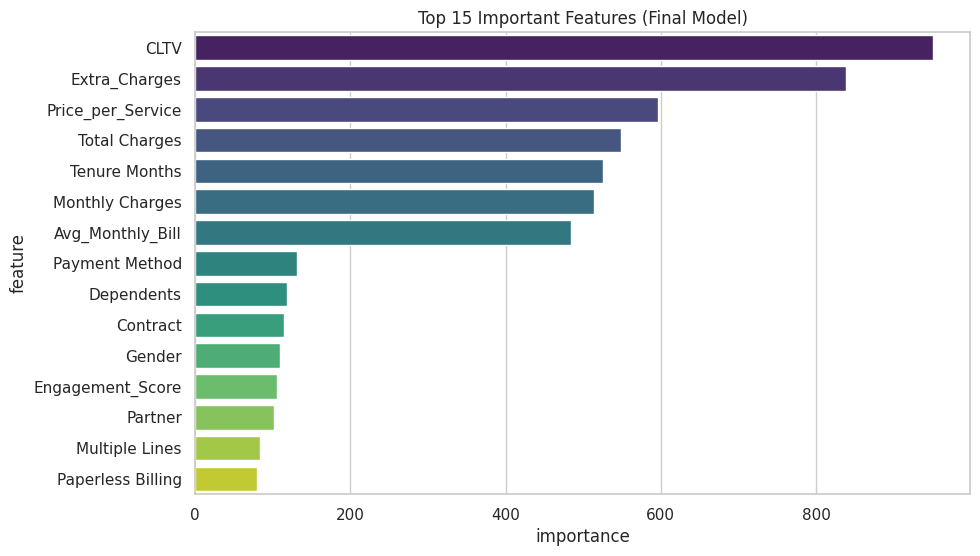

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 최신 모델(model_lgbm_final)의 변수 중요도 데이터프레임 생성
# model_lgbm 대신 model_lgbm_final을 사용하여 개수를 맞춥니다.
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_lgbm_final.feature_importances_
}).sort_values(by='importance', ascending=False)

# 중요도가 낮은 변수 식별 (중요도가 5 미만인 변수)
low_importance_features = feature_importances[feature_importances['importance'] < 5]['feature'].tolist()
print(f'제거할 저중요도 변수 ({len(low_importance_features)}개): {low_importance_features}')

# 데이터셋 업데이트 (중요 변수만 추출)
X_train_reduced = X_train.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)

# 모델 재학습 (축소된 피처 사용)
model_lgbm_reduced = lgb.LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
model_lgbm_reduced.fit(X_train_reduced, y_train)

# 성능 평가
y_pred_reduced = model_lgbm_reduced.predict(X_test_reduced)

print('\n--- Reduced Feature Model Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_reduced):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_reduced))

# 상위 15개 변수 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='viridis')
plt.title('Top 15 Important Features (Final Model)')
plt.show()

## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# 튜닝할 파라미터 범위 확장
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [-1, 10, 15],
    'min_child_samples': [10, 20, 30]
}

# LightGBM 모델 초기화
lgbm_final = lgb.LGBMClassifier(random_state=42)

# GridSearchCV 설정
grid_search_final = GridSearchCV(
    estimator=lgbm_final,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 최적화 실행 (Reduced Feature Set 사용)
grid_search_final.fit(X_train_reduced, y_train)

print(f'최적 파라미터: {grid_search_final.best_params_}')

# 최종 모델 평가
final_model = grid_search_final.best_estimator_
y_pred_final = final_model.predict(X_test_reduced)

print('\n--- Final Optimized Model Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1682
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
최적 파라미터: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 30, 'n_estimators': 100, 'num_leaves': 20}

--- Final Optimized Model Evaluation ---
Accuracy: 0.8006

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 학습에서 제외할 컬럼 정의 (ID, 타겟값, 그리고 원본 범주형 컬럼들)
# Churn_Numeric을 제외한 모든 수치형/인코딩된 변수를 학습에 사용합니다.
features_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
                    'Lat Long', 'Latitude', 'Longitude', 'Churn Label',
                    'Churn Value', 'Churn Score', 'Churn_Numeric', 'Churn Reason', 'Churn_Probability']

# 데이터 준비
X = df.drop(columns=[c for c in features_to_drop if c in df.columns])
y = df['Churn_Numeric']

# 2. 범주형 변수 라벨 인코딩
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# 3. 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"최종 업데이트된 학습 데이터 크기: {X_train.shape}")
print(f"학습에 사용된 주요 피처: {list(X.columns)[:10]} ... 등 총 {len(X.columns)}개")

최종 업데이트된 학습 데이터 크기: (5634, 39)
학습에 사용된 주요 피처: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup'] ... 등 총 39개


## LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1688
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
--- Final Enhanced Model Evaluation ---
Accuracy: 0.8084

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg

<Figure size 1000x800 with 0 Axes>

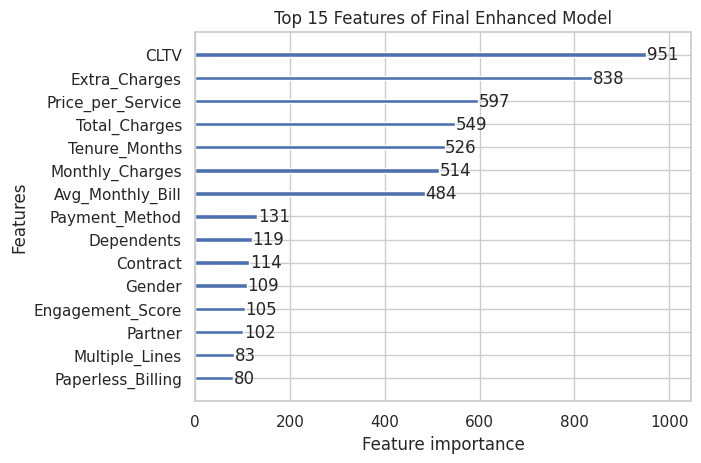

In [ ]:
# 최적화된 파라미터(그리드 서치 결과 반영)를 적용하여 재학습
# 이전 튜닝 결과인 learning_rate=0.05, num_leaves=20 등을 참고합니다.
model_lgbm_final = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31
)
model_lgbm_final.fit(X_train, y_train)

# 예측 및 평가
y_pred = model_lgbm_final.predict(X_test)

print("--- Final Enhanced Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 변수 중요도 시각화
plt.figure(figsize=(10, 8))
lgb.plot_importance(model_lgbm_final, max_num_features=15, importance_type='split')
plt.title('Top 15 Features of Final Enhanced Model')
plt.show()

## Ensemble

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# 개별 모델 정의 (이미 튜닝된 파라미터 반영)
# LightGBM
lgbm_model = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31
)

# Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=4
)

# 앙상블 모델(Soft Voting) 구성
voting_model = VotingClassifier(
    estimators=[('lgbm', lgbm_model), ('rf', rf_model)],
    voting='soft'
)

# 모델 학습
voting_model.fit(X_train, y_train)

# 성능 평가
y_pred_voting = voting_model.predict(X_test)
y_pred_proba_voting = voting_model.predict_proba(X_test)[:, 1]

print('--- Ensemble (Voting) Model Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}')
print(f'AUC Score: {roc_auc_score(y_test, y_pred_proba_voting):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_voting))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1688
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
--- Ensemble (Voting) Model Evaluation ---
Accuracy: 0.8055
AUC Score: 0.8542

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73  

## AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# 최종 앙상블 모델의 예측 확률값 사용
y_pred_proba_final = voting_model.predict_proba(X_test)[:, 1]

# AUC 계산
auc_score_final = roc_auc_score(y_test, y_pred_proba_final)

print(f'최종 앙상블 모델의 AUC Score: {auc_score_final:.4f}')

최종 앙상블 모델의 AUC Score: 0.8544
